####Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.model_selection import GridSearchCV

from sklearn.naive_bayes import MultinomialNB

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import LinearSVC

from xgboost import XGBClassifier

####Load Features

In [2]:
X_train = joblib.load(
    "/content/X_train.pkl"
)

X_test = joblib.load(
    "/content/X_test.pkl"
)

y_train = joblib.load(
    "/content/y_train.pkl"
)

y_test = joblib.load(
    "/content/y_test.pkl"
)

class_weights = {
    0:0.49,
    1:7.94,
    2:1.20
}

####Create Function

In [3]:
file_path = "/content/train_model.py"
os.makedirs(os.path.dirname(file_path), exist_ok=True)

content = """
# Model Training Module
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name
):
    model.fit(
        X_train,
        y_train
    )
    prediction = model.predict(
        X_test
    )
    result = {
        "Model":model_name,
        "Accuracy":accuracy_score(
            y_test,
            prediction
        ),
        "Precision":precision_score(
            y_test,
            prediction,
            average="weighted"
        ),
        "Recall":recall_score(
            y_test,
            prediction,
            average="weighted"
        ),
        "Macro F1":f1_score(
            y_test,
            prediction,
            average="macro"
        ),
        "Weighted F1":f1_score(
            y_test,
            prediction,
            average="weighted"
        )
    }
    return result
"""

with open(file_path, "w") as f:
    f.write(content)

print("train_model.py updated with evaluate_model function!")

train_model.py updated with evaluate_model function!


In [4]:
file_path = "Shopease/src/train_model.py"
os.makedirs(os.path.dirname(file_path), exist_ok=True)

content = """
# Model Training Module
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    model_name
):
    model.fit(
        X_train,
        y_train
    )
    prediction = model.predict(
        X_test
    )
    result = {
        "Model":model_name,
        "Accuracy":accuracy_score(
            y_test,
            prediction
        ),
        "Precision":precision_score(
            y_test,
            prediction,
            average="weighted"
        ),
        "Recall":recall_score(
            y_test,
            prediction,
            average="weighted"
        ),
        "Macro F1":f1_score(
            y_test,
            prediction,
            average="macro"
        ),
        "Weighted F1":f1_score(
            y_test,
            prediction,
            average="weighted"
        )
    }
    return result
"""

with open(file_path, "w") as f:
    f.write(content)

print("train_model.py updated with evaluate_model function!")

train_model.py updated with evaluate_model function!


####Create Models

In [5]:
models = {

"Naive Bayes":

MultinomialNB(),

"Logistic Regression":

LogisticRegression(

    class_weight=class_weights,

    max_iter=1000,

    random_state=42

),

"Random Forest":

RandomForestClassifier(

    n_estimators=300,

    random_state=42

),

"Linear SVM":

LinearSVC(

    class_weight=class_weights

),

"XGBoost":

XGBClassifier(

    random_state=42,

    eval_metric="mlogloss"

)

}

####Train All Models

In [8]:
import sys
import os

# Define shopease_root_dir to avoid ambiguity
shopease_root_dir = '/content/Shopease'

# Add 'Shopease's parent directory to sys.path to find 'src' module
if shopease_root_dir not in sys.path:
    sys.path.insert(0, shopease_root_dir)

# Ensure src directory is recognized as a package (redundant if already done, but harmless)
src_dir = os.path.join(shopease_root_dir, "src")
os.makedirs(src_dir, exist_ok=True)
init_file_path = os.path.join(src_dir, "__init__.py")
if not os.path.exists(init_file_path):
    open(init_file_path, 'a').close() # Create empty __init__.py if it doesn't exist

# Import the function after path setup
from src.train_model import evaluate_model

results = []

for name, model in models.items():

    score = evaluate_model(

        model,

        X_train,

        X_test,

        y_train,

        y_test,

        name

    )

    results.append(score)

####Comparison Table

In [9]:
results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
0,Naive Bayes,0.873189,0.835870,0.873189,0.577925,0.852254
1,Logistic Regression,0.834481,0.883450,0.834481,0.633614,0.856429
2,Random Forest,0.859416,0.821814,0.859416,0.566793,0.839251
3,Linear SVM,0.880551,0.869683,0.880551,0.631344,0.874623
4,XGBoost,0.869865,0.846660,0.869865,0.590495,0.852372


In [10]:
results.sort_values(

    "Macro F1",

    ascending=False

)

,Model,Accuracy,Precision,Recall,Macro F1,Weighted F1
1,Logistic Regression,0.834481,0.883450,0.834481,0.633614,0.856429
3,Linear SVM,0.880551,0.869683,0.880551,0.631344,0.874623
4,XGBoost,0.869865,0.846660,0.869865,0.590495,0.852372
0,Naive Bayes,0.873189,0.835870,0.873189,0.577925,0.852254
2,Random Forest,0.859416,0.821814,0.859416,0.566793,0.839251


####Save

In [11]:
os.makedirs("outputs/metrics", exist_ok=True)

results.to_csv(

    "outputs/metrics/model_comparison.csv",

    index=False

)

####Hyperparameter Tuning

#####Logistic Regression

In [12]:
parameters = {

"C":[

0.01,

0.1,

1,

5,

10

]

}

#####Grid Search

In [13]:
grid = GridSearchCV(

LogisticRegression(

class_weight=class_weights,

max_iter=1000

),

parameters,

cv=5,

scoring="f1_macro",

n_jobs=-1

)

#####Fit

In [14]:
grid.fit(

X_train,

y_train

)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight={0: 0.49, 1: 7.94,
                                                        2: 1.2},
                                          max_iter=1000),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 5, 10]},
             scoring='f1_macro')

#####Best

In [15]:
best_model = grid.best_estimator_

best_model

LogisticRegression(C=1, class_weight={0: 0.49, 1: 7.94, 2: 1.2}, max_iter=1000)

####Evaluate Best Model

In [16]:
prediction = best_model.predict(

X_test
)

####Classification Report

In [17]:
from sklearn.metrics import classification_report

report = classification_report(

y_test,

prediction
)

print(report)

              precision    recall  f1-score   support

           0       0.94      0.89      0.91      2870
           1       0.12      0.29      0.17       177
           2       0.86      0.78      0.82      1164

    accuracy                           0.83      4211
   macro avg       0.64      0.65      0.63      4211
weighted avg       0.88      0.83      0.86      4211



In [18]:
os.makedirs("outputs/reports", exist_ok=True)

with open(

"outputs/reports/classification_report.txt",

"w"

) as f:

    f.write(report)

####Confusion Matrix

In [20]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(

y_test,

prediction
)

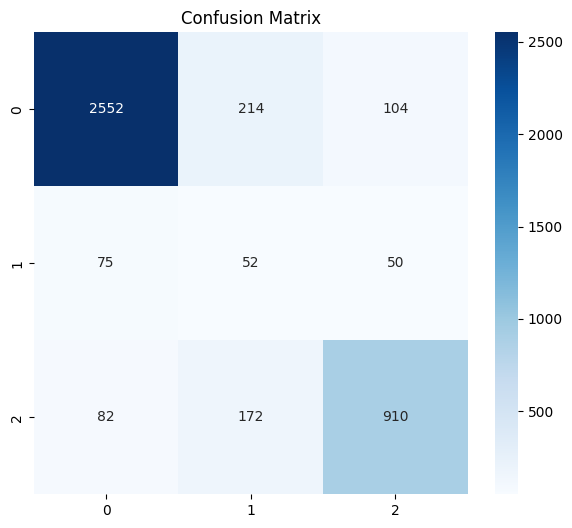

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("outputs/figures", exist_ok=True)

plt.figure(

figsize=(7,6)

)

sns.heatmap(

matrix,

annot=True,

fmt="d",

cmap="Blues"

)

plt.title(

"Confusion Matrix"

)

plt.savefig(

"outputs/figures/confusion_matrix.png",

dpi=300,

bbox_inches="tight"

)

plt.show()

####ROC Curve

In [23]:
from sklearn.preprocessing import label_binarize

from sklearn.metrics import roc_curve

from sklearn.metrics import auc

####One-vs-Rest

In [24]:
y_score = best_model.predict_proba(

X_test
)

y_bin = label_binarize(

y_test,

classes=[0,1,2]

)

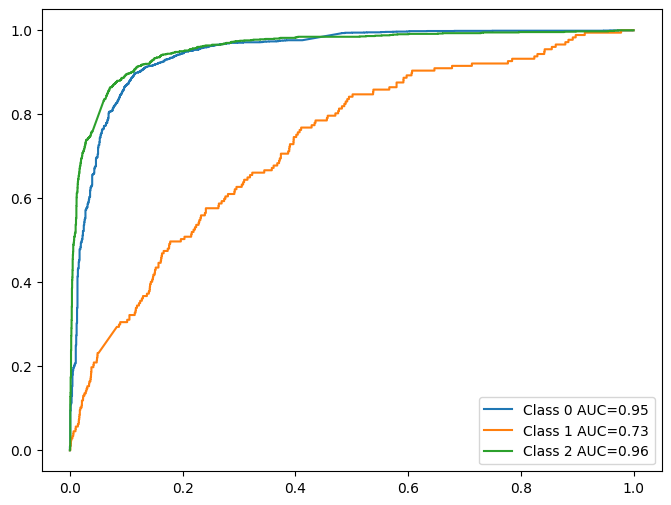

In [25]:
plt.figure(figsize=(8,6))

for i in range(3):

    fpr,tpr,_ = roc_curve(

        y_bin[:,i],

        y_score[:,i]

    )

    plt.plot(

        fpr,

        tpr,

        label=f"Class {i} AUC={auc(fpr,tpr):.2f}"

    )

plt.legend()

plt.savefig(

"outputs/figures/roc_curve.png",

dpi=300

)

plt.show()

####Feature Importance
#####Only for Logistic Regression

In [27]:
tfidf = joblib.load(
    "/content/tfidf_vectorizer.pkl"
)

In [28]:
importance = pd.DataFrame({

"Word":

tfidf.get_feature_names_out(),

"Importance":

np.mean(

np.abs(

best_model.coef_

),

axis=0

)

})

####Top

In [29]:
importance = importance.sort_values(

"Importance",

ascending=False

).head(30)

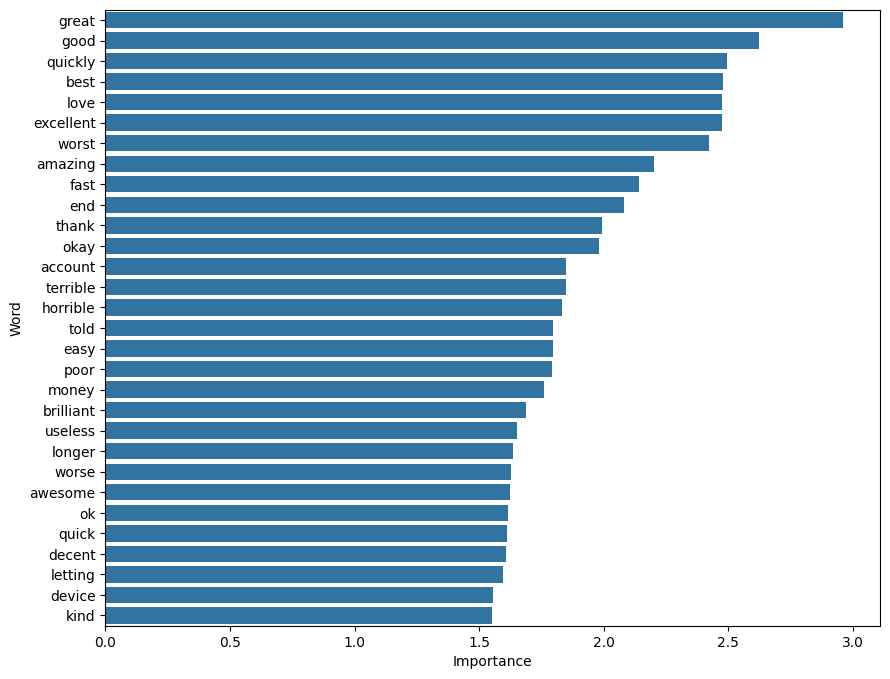

In [30]:
plt.figure(

figsize=(10,8)

)

sns.barplot(

data=importance,

x="Importance",

y="Word"

)

plt.savefig(

"outputs/figures/feature_importance.png",

dpi=300,

bbox_inches="tight"

)

plt.show()

####Save Model

In [31]:
os.makedirs("models", exist_ok=True)
joblib.dump(

best_model,

"models/best_sentiment_model.pkl"

)

['models/best_sentiment_model.pkl']

####Save Metrics

In [32]:
metrics = pd.DataFrame({

"Accuracy":[

accuracy_score(

y_test,

prediction

)

],

"Macro F1":[

f1_score(

y_test,

prediction,

average="macro"

)

],

"Weighted F1":[

f1_score(

y_test,

prediction,

average="weighted"

)

]

})

In [33]:
metrics.to_csv(

"outputs/metrics/model_metrics.csv",

index=False

)

In [34]:
joblib.dump(models["Naive Bayes"], "models/naive_bayes.pkl")
joblib.dump(models["Logistic Regression"], "models/logistic_regression.pkl")
joblib.dump(models["Random Forest"], "models/random_forest.pkl")
joblib.dump(models["Linear SVM"], "models/linear_svm.pkl")
joblib.dump(models["XGBoost"], "models/xgboost.pkl")

['models/xgboost.pkl']